# Importacion de liberias

In [3]:
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt
import seaborn as sns

from funciones2 import adfuller_test, correlacion_vs_target


# Cargue de datos

In [4]:
df_recaudo = pd.read_excel('../data/raw/dataset_recaudo.xlsx')

# Exploracion de los datos

In [5]:
df_recaudo.head()

,fecha,recaudo,empresas,trabajadores,salario_minimo,salario_promedio,masa_salarial,desempleo,inflacion,pib,trm,precio_petroleo,indice_confianza
0,2015-01-01,46478701032,40820,734036,644350,1674050,1228812965800,9.733869,4.408684,99.836234,2875.14,63.14,97.23
1,2015-02-01,49215210366,41367,741762,644350,1641916,1217910895992,9.914997,4.454307,100.733155,2899.45,65.10,101.88
2,2015-03-01,46665373688,41091,741667,644350,1531909,1136166352303,10.330259,4.514485,100.284449,2905.54,72.21,100.47
3,2015-04-01,49184725954,41267,740846,644350,1685844,1248950784024,10.745001,4.704474,100.605416,2932.18,70.21,103.67
4,2015-05-01,53929007933,41909,752405,644350,1739668,1308934901540,10.651245,5.019500,102.972624,2960.10,74.87,104.45


In [6]:
df_recaudo.isna().sum()

fecha               0
recaudo             0
empresas            0
trabajadores        0
salario_minimo      0
salario_promedio    0
masa_salarial       0
desempleo           0
inflacion           0
pib                 0
trm                 0
precio_petroleo     0
indice_confianza    0
dtype: int64

In [7]:
df_recaudo.duplicated().sum()

0

In [8]:
df_recaudo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   fecha             132 non-null    datetime64[ns]
 1   recaudo           132 non-null    int64         
 2   empresas          132 non-null    int64         
 3   trabajadores      132 non-null    int64         
 4   salario_minimo    132 non-null    int64         
 5   salario_promedio  132 non-null    int64         
 6   masa_salarial     132 non-null    int64         
 7   desempleo         132 non-null    float64       
 8   inflacion         132 non-null    float64       
 9   pib               132 non-null    float64       
 10  trm               132 non-null    float64       
 11  precio_petroleo   132 non-null    float64       
 12  indice_confianza  132 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(6)
memory usage: 13.5 KB


In [9]:
df_recaudo.describe()

,fecha,recaudo,empresas,trabajadores,salario_minimo,salario_promedio,masa_salarial,desempleo,inflacion,pib,trm,precio_petroleo,indice_confianza
count,132,1.320000e+02,132.00000,1.320000e+02,1.320000e+02,1.320000e+02,1.320000e+02,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,2020-06-16 02:10:54.545454592,1.083811e+11,52858.94697,9.514843e+05,9.409735e+05,2.448215e+06,2.410140e+12,10.450953,4.224089,123.353640,3323.316288,64.126212,99.555455
min,2015-01-01 00:00:00,4.647870e+10,40820.00000,7.340360e+05,6.443500e+05,1.531909e+06,1.136166e+12,8.444964,2.873905,99.836234,2752.620000,45.770000,82.980000
25%,2017-09-23 12:00:00,6.996771e+10,46793.25000,8.478132e+05,7.377170e+05,1.950402e+06,1.632420e+12,9.590331,3.661075,110.983334,3069.720000,56.395000,95.200000
50%,2020-06-16 00:00:00,8.640238e+10,50869.50000,9.164015e+05,8.778030e+05,2.280315e+06,2.068256e+12,10.453877,4.300818,118.437653,3335.805000,63.335000,100.635000
75%,2023-03-08 18:00:00,1.475975e+11,59736.00000,1.077592e+06,1.160000e+06,2.997229e+06,3.230169e+12,11.009414,4.657612,136.799210,3585.460000,72.120000,104.277500
max,2025-12-01 00:00:00,2.238215e+11,66192.00000,1.195582e+06,1.423500e+06,3.786787e+06,4.391745e+12,14.184200,5.943765,150.933005,4012.780000,81.910000,109.710000
std,NaN,5.025949e+10,7331.98488,1.320380e+05,2.438326e+05,6.400537e+05,9.637971e+11,1.163458,0.716687,15.367831,316.170570,8.870350,6.102427


In [13]:
df_recaudo['fecha'].unique()

<DatetimeArray>
['2015-01-01 00:00:00', '2015-02-01 00:00:00', '2015-03-01 00:00:00',
 '2015-04-01 00:00:00', '2015-05-01 00:00:00', '2015-06-01 00:00:00',
 '2015-07-01 00:00:00', '2015-08-01 00:00:00', '2015-09-01 00:00:00',
 '2015-10-01 00:00:00',
 ...
 '2025-03-01 00:00:00', '2025-04-01 00:00:00', '2025-05-01 00:00:00',
 '2025-06-01 00:00:00', '2025-07-01 00:00:00', '2025-08-01 00:00:00',
 '2025-09-01 00:00:00', '2025-10-01 00:00:00', '2025-11-01 00:00:00',
 '2025-12-01 00:00:00']
Length: 132, dtype: datetime64[ns]

### Descomposición de series de tiempo

recaudo    0
dtype: int64


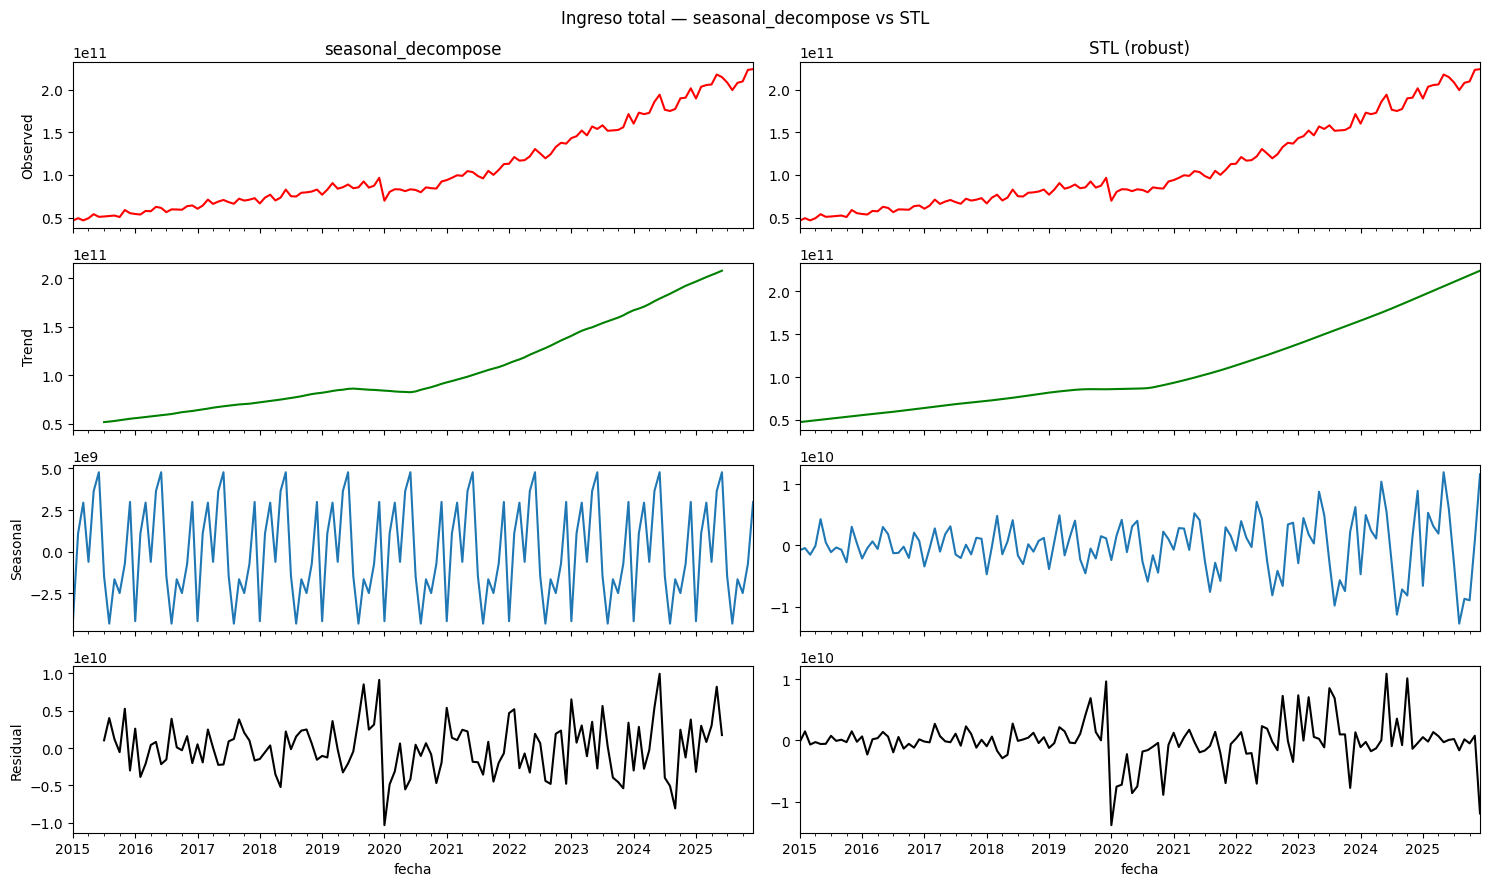

In [ ]:

# --- Preparación de la serie ---
df_serie = df_recaudo[["fecha", "recaudo"]].copy()
df_serie["fecha"] = pd.to_datetime(df_serie["fecha"], dayfirst=True)
df_serie = df_serie.set_index("fecha").asfreq('MS')

nans = df_serie.isna().sum()
print(nans)
# --- Descomposición: dos métodos ---
result = seasonal_decompose(df_serie['recaudo'], model='additive', period=12)
result_stl = STL(df_serie['recaudo'], period=12, robust=True).fit()

# --- Gráfica comparativa ---
fig, axes = plt.subplots(4, 2, sharex=True, figsize=(15, 9))
fig.suptitle("Ingreso total — seasonal_decompose vs STL")

# seasonal_decompose
result.observed.plot(ax=axes[0, 0], legend=False, color='r')
axes[0, 0].set_ylabel('Observed')
axes[0, 0].set_title('seasonal_decompose')
result.trend.plot(ax=axes[1, 0], legend=False, color='g')
axes[1, 0].set_ylabel('Trend')
result.seasonal.plot(ax=axes[2, 0], legend=False)
axes[2, 0].set_ylabel('Seasonal')
result.resid.plot(ax=axes[3, 0], legend=False, color='k')
axes[3, 0].set_ylabel('Residual')

# STL
result_stl.observed.plot(ax=axes[0, 1], legend=False, color='r')
axes[0, 1].set_title('STL (robust)')
result_stl.trend.plot(ax=axes[1, 1], legend=False, color='g')
result_stl.seasonal.plot(ax=axes[2, 1], legend=False)
result_stl.resid.plot(ax=axes[3, 1], legend=False, color='k')

plt.tight_layout()
plt.show()

def a_dataframe(res, metodo):
    df = pd.DataFrame({
        'fecha': res.resid.index,
        'resid': res.resid.values,
        'seasonal': res.seasonal.values,
        'trend': res.trend.values,
    })
    df['metodo'] = metodo
    return df

complete_result = pd.concat([
    a_dataframe(result, 'seasonal_decompose'),
    a_dataframe(result_stl, 'STL'),
], ignore_index=True)

complete_result["cod_unico"] = "ingreso_total"

#### Test de estacionalidad (periodicidad)

In [34]:
df_serie = df_recaudo.copy()
stationary = adfuller_test(df_serie.recaudo, name="recaudo_total")

    Augmented Dickey-Fuller Test on "recaudo_total" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = 1.6045
 No. Lags Chosen       = 13
 Critical value 1%     = -3.487
 Critical value 5%     = -2.886
 Critical value 10%    = -2.58
 => P-Value = 0.9979. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


In [37]:
serie_diff = df_serie["recaudo"].diff().dropna()

In [41]:
adfuller_test(serie_diff, name="recaudo_total (1ra diferencia)")

    Augmented Dickey-Fuller Test on "recaudo_total (1ra diferencia)" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.6326
 No. Lags Chosen       = 12
 Critical value 1%     = -3.487
 Critical value 5%     = -2.886
 Critical value 10%    = -2.58
 => P-Value = 0.4661. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


0

In [57]:
serie_log = np.log(df_serie["recaudo"])

serie_log_diff = serie_log.diff().dropna()

adfuller_test(
    serie_log_diff,
    name="Log(Recaudo) - Primera diferencia"
)

 Augmented Dickey-Fuller Test on "Log(Recaudo) - Primera diferencia" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -2.6904
 No. Lags Chosen       = 12
 Critical value 1%     = -3.487
 Critical value 5%     = -2.886
 Critical value 10%    = -2.58
 => P-Value = 0.0757. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


0

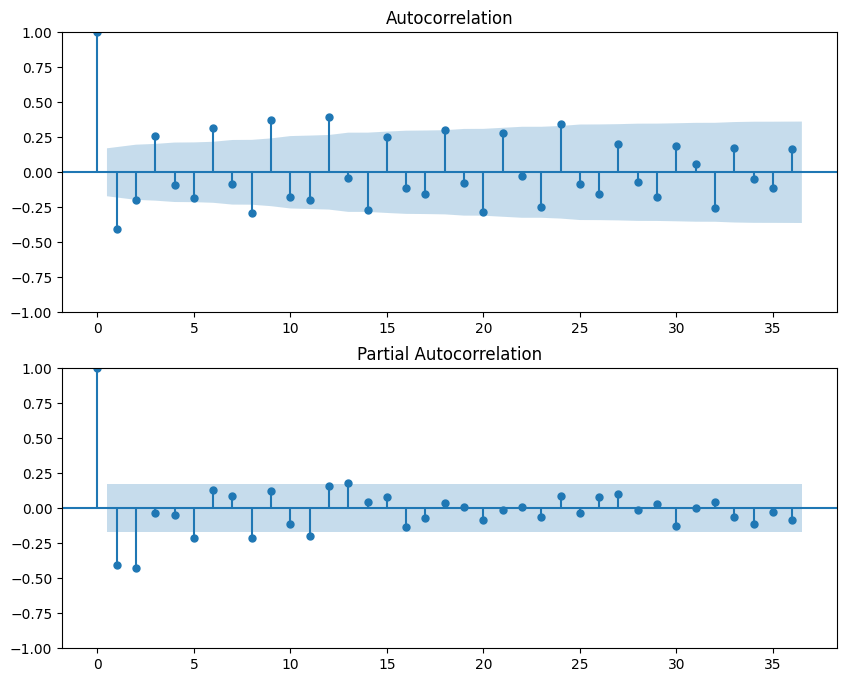

In [58]:
fig, ax = plt.subplots(2,1, figsize=(10,8))

plot_acf(serie_log_diff, lags=36, ax=ax[0])

plot_pacf(serie_log_diff,
          lags=36,
          method="ywm",
          ax=ax[1])

plt.show()

### Correlación de variables

In [42]:
corr=df_recaudo.corr(numeric_only=True)

In [43]:
corr

,recaudo,empresas,trabajadores,salario_minimo,salario_promedio,masa_salarial,desempleo,inflacion,pib,trm,precio_petroleo,indice_confianza
recaudo,1.000000,0.962824,0.962737,0.987806,0.988157,0.993393,-0.131471,0.091765,0.969272,0.903310,0.041495,0.147647
empresas,0.962824,1.000000,0.999797,0.964729,0.962659,0.970755,-0.094748,0.151831,0.992482,0.952196,-0.028866,0.127703
trabajadores,0.962737,0.999797,1.000000,0.964561,0.962213,0.970564,-0.097140,0.154731,0.992192,0.952080,-0.025901,0.129921
salario_minimo,0.987806,0.964729,0.964561,1.000000,0.997127,0.997404,-0.060991,0.049409,0.962101,0.911042,0.020069,0.111731
salario_promedio,0.988157,0.962659,0.962213,0.997127,1.000000,0.998121,-0.057970,0.044127,0.959510,0.908411,0.014132,0.100288
masa_salarial,0.993393,0.970755,0.970564,0.997404,0.998121,1.000000,-0.084498,0.073333,0.970679,0.915954,0.025653,0.125821
desempleo,-0.131471,-0.094748,-0.097140,-0.060991,-0.057970,-0.084498,1.000000,-0.322372,-0.155381,-0.057429,-0.206660,-0.560932
inflacion,0.091765,0.151831,0.154731,0.049409,0.044127,0.073333,-0.322372,1.000000,0.177933,0.090667,0.154302,0.532346
pib,0.969272,0.992482,0.992192,0.962101,0.959510,0.970679,-0.155381,0.177933,1.000000,0.935838,-0.009331,0.191686
trm,0.903310,0.952196,0.952080,0.911042,0.908411,0.915954,-0.057429,0.090667,0.935838,1.000000,-0.063141,0.050366


In [47]:
resultado_correlacion = correlacion_vs_target(df_recaudo, target_col='recaudo')
print(resultado_correlacion)

            variable  correlacion       metodo        p_value
0              fecha     1.000000  Eta Squared            NaN
1      masa_salarial     0.993393      Pearson  4.190737e-124
2   salario_promedio     0.988157      Pearson  1.056666e-107
3     salario_minimo     0.987806      Pearson  6.951623e-107
4                pib     0.969272      Pearson   4.750561e-81
5           empresas     0.962824      Pearson   9.224322e-76
6       trabajadores     0.962737      Pearson   1.069410e-75
7                trm     0.903310      Pearson   1.274842e-49
8   indice_confianza     0.147647      Pearson   9.112937e-02
9          desempleo     0.131471      Pearson   1.329294e-01
10         inflacion     0.091765      Pearson   2.953389e-01
11   precio_petroleo     0.041495      Pearson   6.366313e-01


c:\Program Files\Python311\Lib\site-packages\scipy\stats\_stats_py.py:4141: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(stats.DegenerateDataWarning(msg))


Debido a la alto multicolinealidad en algunas variables se decide analizar el comportamiento de todas las variables a lo largo del tiempo con el fin de identifciar si presentan tendencias y patrones temporales similares a los de la variable objetivo `(Recaudo)`.

#### Comportamiento temporal de las covariables

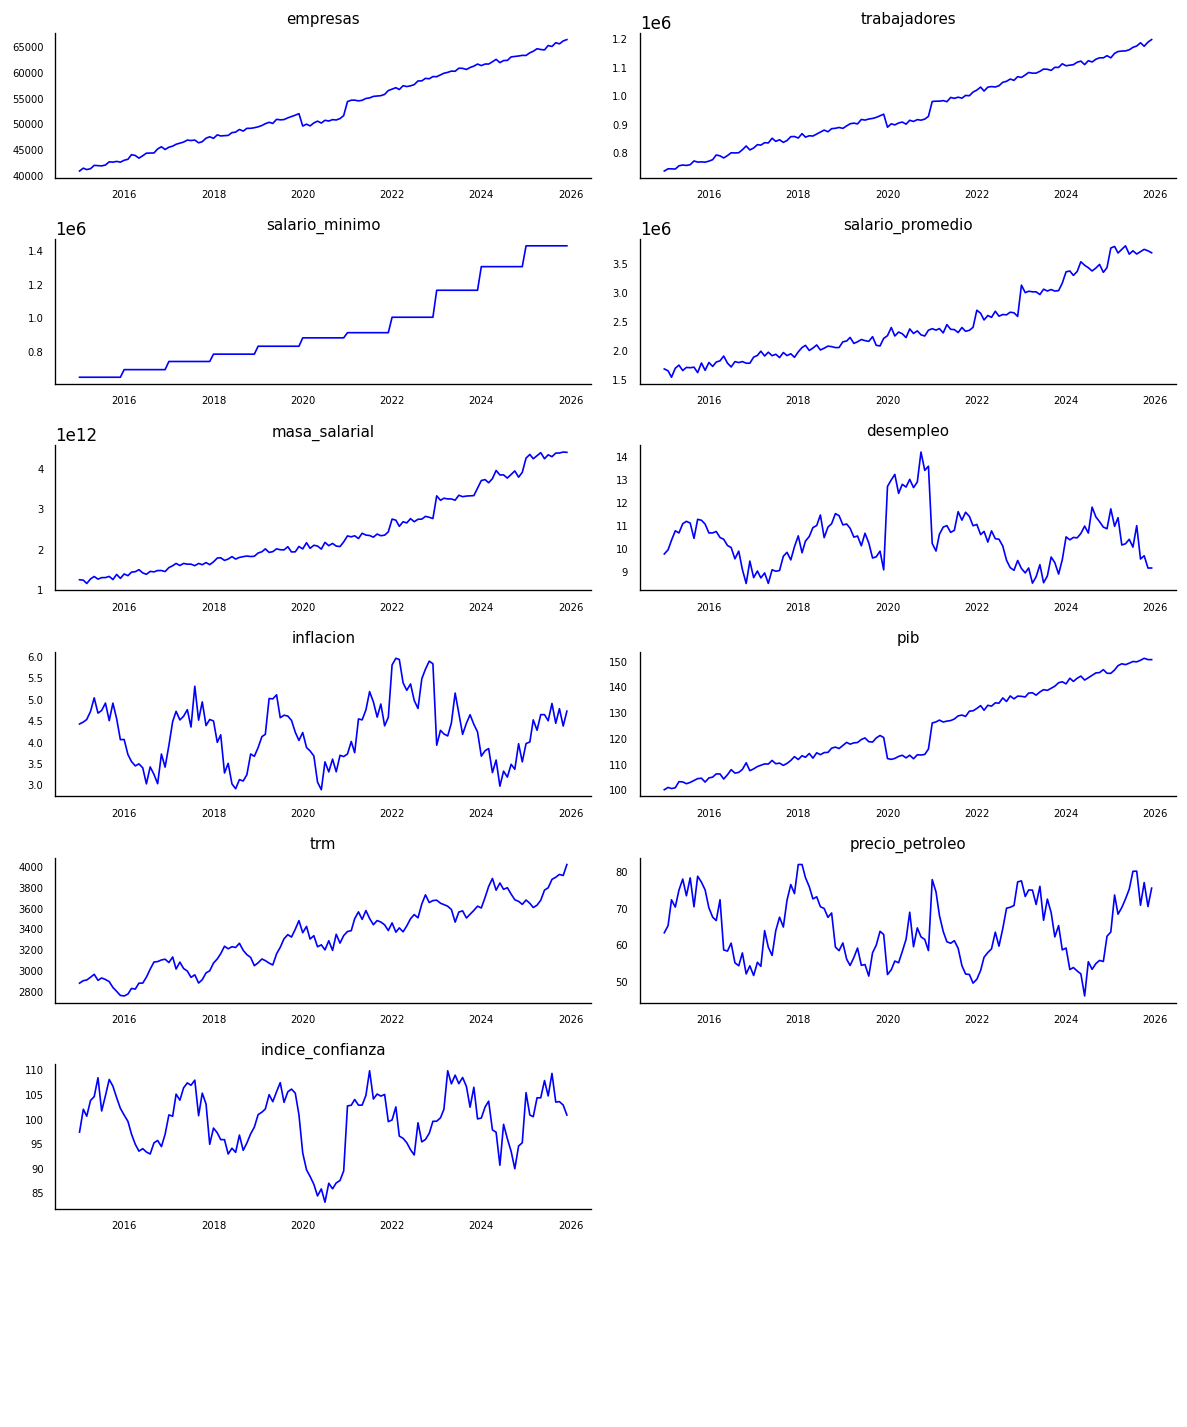

In [54]:
df_plot = df_recaudo.set_index(["fecha"])
variables = df_plot.drop(columns="recaudo")

fig, axes = plt.subplots(
    nrows=7,
    ncols=2,
    figsize=(10, 12),
    dpi=120
)

for i, ax in enumerate(axes.flatten()):

    if i >= len(variables.columns):
        ax.axis("off")
        continue

    data = variables.iloc[:, i]

    ax.plot(data, color="blue", linewidth=1)
    ax.set_title(variables.columns[i], fontsize=9)

    ax.xaxis.set_ticks_position("none")
    ax.yaxis.set_ticks_position("none")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show() 

Al comparar estas series con la variable objetivo recaudo, se observa que:
empresas, trabajadores, masa_salarial, PIB, salario_promedio y, en menor medida, TRM presentan una tendencia creciente similar a la del recaudo, por lo tanto en este punto no se decide descartar ninguna hasta evaluar su contribución en el rendimiento y desempeño de los modelos ha evaluar. 

# Feature engineering

In [ ]:
df_recaudo['mes_prima'] = np.where(df_recaudo['fecha'].dt.month.isin([6,12]),1,0)
df_recaudo['mes'] = df_recaudo['fecha'].dt.month
df_recaudo['year'] = df_recaudo['fecha'].dt.year
df_recaudo['trimestre'] = 'T' + df_recaudo['fecha'].dt.quarter.astype(str)

In [70]:
# Rezagos mensuales
df_recaudo["lag_1"] = df_recaudo["recaudo"].shift(1)
df_recaudo["lag_2"] = df_recaudo["recaudo"].shift(2)
df_recaudo["lag_3"] = df_recaudo["recaudo"].shift(3)
df_recaudo["lag_6"] = df_recaudo["recaudo"].shift(6)
df_recaudo["lag_12"] = df_recaudo["recaudo"].shift(12)

# Promedios móviles
df_recaudo["ma_3"] = df_recaudo["recaudo"].shift(1).rolling(3).mean()
df_recaudo["ma_6"] = df_recaudo["recaudo"].shift(1).rolling(6).mean()
df_recaudo["ma_12"] = df_recaudo["recaudo"].shift(1).rolling(12).mean()

# Desviación
df_recaudo["std_6"] = df_recaudo["recaudo"].shift(1).rolling(6).std()

# Cambio porcentual
df_recaudo["pct_1"] = df_recaudo["recaudo"].pct_change()
df_recaudo["pct_12"] = df_recaudo["recaudo"].pct_change(12)

In [72]:
df_recaudo.to_excel('../data/processed/dataset_recaudo.xlsx', index=False)